In [1]:
# import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, f1_score, precision_score, recall_score)
from sklearn.base import BaseEstimator, ClassifierMixin
from datetime import datetime
import os

# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

In [2]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
torch.use_deterministic_algorithms(True)  # will error if a nondeterministic op is used
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# optional but often helps remove GPU variability
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False


In [3]:
# create timestamp folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

output_dir = f"model_results/nn_embedding_only_clf_intensity_results/{timestamp}"
os.makedirs(output_dir, exist_ok=True)

In [4]:
# option for saving ALL predictions as a pkl file (the file likely will be around 2 gb)
save_predictions_pkl = False

In [5]:
# set seed
seed = 42
import random
random.seed(seed)
np.random.seed(seed)

# set seed for pytorch
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ensure deterministic behavior for cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# pytorch generator for dataloader
torch_generator = torch.Generator().manual_seed(seed)

os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [6]:
# read in main csv file to get target values
main_df = pd.read_csv("../data/unified_features/unified_features_final.csv",low_memory = False)
intensity_values_df = pd.read_csv('../data/condenseq_data/condenseq_intensity_bins.csv')
main_df = main_df.merge(intensity_values_df, on='protein_seq', how='left')
main_df = main_df.rename(columns={'protein_seq': 'seq'})

In [7]:
# embeddings file paths
embedding_paths = {'seqvec': r"../data/embeddings/bio_embeddings/seqvec_embeddings.csv", 
                   'bepler': r"../data/embeddings/bio_embeddings/bepler_embeddings.csv", 
                   'cpcprot': r"../data/embeddings/bio_embeddings/cpcprot_embeddings.csv", 
                   'esm': r"../data/embeddings/bio_embeddings/esm_embeddings.csv", 
                   'esm1b': r"../data/embeddings/bio_embeddings/esm1b_embeddings.csv",
                   'esm2': r"../data/embeddings/bio_embeddings/esm2_embeddings.csv",
                   'plusrnn': r"../data/embeddings/bio_embeddings/plusrnn_embeddings.csv",
                   'prottrans_bert_bfd': r"../data/embeddings/bio_embeddings/prottrans_bert_bfd.csv"
                }

In [8]:
# define feature columns
og_feature_cols = [
    'fraction_A','fraction_C','fraction_D','fraction_E','fraction_F','fraction_G','fraction_H','fraction_I','fraction_K','fraction_L','fraction_M',
    'fraction_N','fraction_P','fraction_Q','fraction_R','fraction_S','fraction_T','fraction_V','fraction_W','fraction_Y',
    'fraction_group_ILMV','fraction_group_RK','fraction_group_DE','fraction_group_GS','fraction_group_YFW',
    'NCPR','FCR','fraction_disorder_promoting','mean_hydropathy',
    'frac_disorder','omega_STNQCH','kappa_STNQCH_ILMV','kappa_STNQCH_RK','kappa_STNQCH_ED',
    'kappa_STNQCH_FWY','kappa_STNQCH_A','kappa_STNQCH_P','kappa_STNQCH_G','omega_ILMV','kappa_ILMV_RK','kappa_ILMV_ED',
    'kappa_ILMV_FWY','kappa_ILMV_A','kappa_ILMV_P','kappa_ILMV_G','omega_RK','kappa_RK_ED','kappa_RK_FWY','kappa_RK_A',
    'kappa_RK_P','kappa_RK_G','omega_ED','kappa_ED_FWY','kappa_ED_A','kappa_ED_P','kappa_ED_G','omega_FWY',
    'kappa_FWY_A','kappa_FWY_P','kappa_FWY_G','omega_A','kappa_A_P','kappa_A_G','omega_P','kappa_P_G','omega_G',
    'fraction_R_of_RK','fraction_D_of_DE','fraction_S_of_SG','fraction_N_of_NQ','fraction_Y_of_YF','fraction_F_of_FW',
    'fraction_Y_of_YW','fraction_R_of_RQ','fraction_K_of_KQ','fraction_group_ILV','fraction_FYW_of_FYWILV','fraction_FYW_of_FYWR', 
]

new_feature_cols = [
    'lcr_residues',
    'radius_of_gyration', 'scaling_exponent', 'asphericity',
    'pslab_delta_g', 'pslab_saturation_mgml', 'finches_heterotypic_epsilon',
    'finches_homotypic_epsilon'
]

bryans_feature_cols = [ 
    'frac_polar', 'frac_hydrophobic', 'frac_tiny', 'frac_small', 
    'frac_aliphatic', 'charge_ratio', 'polar_nonpolar_ratio', 
    'molecular_weight', 'isoelectric_point', 'scd', 'charge_segregation', 
    'hydrophobic_moment', 'aromatic_clustering', 'frac_sticker', 'frac_spacer', 'sticker_spacer_ratio', 'max_sticker_spacing', 
    'meta_disorder_mean', 'meta_disorder_max'
]

extra_feature_cols = [
    'calvados_ah_pairs'
]

mi_threshold_feature_set = ['polar_nonpolar_ratio',
 'frac_disorder',
 'frac_hydrophobic',
 'isoelectric_point',
 'mean_hydropathy',
 'omega_FWY',
 'aromatic_clustering',
 'fraction_FYW_of_FYWILV',
 'kappa_ILMV_FWY',
 'fraction_disorder_promoting',
 'sticker_spacer_ratio',
 'meta_disorder_mean',
 'omega_ILMV',
 'calvados_ah_pairs',
 'kappa_FWY_P',
 'omega_P',
 'meta_disorder_max',
 'scd',
 'molecular_weight',
 'fraction_group_ILMV',
 'fraction_FYW_of_FYWR',
 'kappa_STNQCH_FWY',
 'omega_STNQCH',
 'omega_RK',
 'kappa_ILMV_P']

#feature_cols = og_feature_cols + new_feature_cols + bryans_feature_cols + extra_feature_cols
feature_cols = mi_threshold_feature_set

# save list of features to txt file in timestamp folder
list_file = f"{output_dir}/feature_list.txt"

with open(list_file, 'w') as file:
    for feature in feature_cols:
        file.write(str(feature) + '\n')


In [9]:
# initialize list for storing model results
clf_list = []

In [10]:
# initialize dict for storing model predictions
trained_models_dict = {}
all_predictions_dict = {}

In [11]:
# initialize list of target columns
target_cols = [
    'intensity_bound'
]

In [12]:
# unimodal branch network for marginal representations
class unimodalBranch(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout_rate=0.2):
        
        super().__init__()

        # set seed
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            
        layers = []
        prev_dim = input_dim
        
        # create hidden layers with relu activation
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # batch normalization for stability
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))  # dropout for regularization
            
            prev_dim = h_dim
        
        self.net = nn.Sequential(*layers)
        self.output_dim = hidden_dims[-1] if hidden_dims else input_dim
    
    def forward(self, x):
        return self.net(x)

In [13]:
# fusionNetwork removed - embedding-only model classifies directly off a single MLP branch
# (see embeddingMLPClassifier below)

In [14]:
class embeddingMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, embedding_dim, hidden_dims=[128, 64, 32], lr=0.001, epochs=50, batch_size=32,
                 dropout_rate=0.3, patience=10, min_delta=0.001):

        super().__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dims = hidden_dims
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        self.patience = patience
        self.min_delta = min_delta

        self.train_loss_history = []
        self.val_loss_history = []

        # set seed for reproducibility
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)

        # early stopping tracking
        self.best_val_loss = float('inf')
        self.best_val_accuracy = 0
        self.best_model_state = None
        self.patience_counter = 0

        # device configuration
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # initialize network - a single MLP mapping embeddings straight to class logits
        self._init_network()

        # move network to device
        self.to(self.device)

        # training state
        self.is_fitted = False
        self.train_loss_history = []
        self.val_loss_history = []

    def _init_network(self):
        # regular MLP: embeddings -> hidden layers -> binary classification head
        # (reuses the unimodalBranch block for the hidden layers, then adds a final linear head)
        self.embedding_branch = unimodalBranch(
            input_dim=self.embedding_dim,
            hidden_dims=self.hidden_dims,
            dropout_rate=self.dropout_rate
        )
        self.classifier_head = nn.Linear(self.embedding_branch.output_dim, 2)  # binary classification

    def forward(self, batch_embeddings):
        marginal = self.embedding_branch(batch_embeddings)
        outputs = self.classifier_head(marginal)
        return outputs

    def to(self, device):
        self.device = device
        self.embedding_branch.to(device)
        self.classifier_head.to(device)
        return self

    def fit(self, x_embeddings_train, y_train, x_embeddings_val=None, y_val=None):

        if x_embeddings_val is None or y_val is None:
            raise ValueError("Provide x_embeddings_val/y_val to use premade splits.")

        x_embeddings_train = np.asarray(x_embeddings_train)
        y_train = np.asarray(y_train)

        x_embeddings_val = np.asarray(x_embeddings_val)
        y_val = np.asarray(y_val)

        # convert training data to torch tensors
        x_embeddings_train_tensor = torch.tensor(x_embeddings_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)

        # convert validation data to torch tensors
        x_embeddings_val_tensor = torch.tensor(x_embeddings_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.long)

        # create training dataloader
        train_dataset = TensorDataset(x_embeddings_train_tensor, y_train_tensor)
        train_dataloader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, worker_init_fn=lambda worker_id: torch.manual_seed(seed + worker_id), generator = torch_generator)

        # create validation dataloader
        val_dataset = TensorDataset(x_embeddings_val_tensor, y_val_tensor)
        val_dataloader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False, worker_init_fn=lambda worker_id: torch.manual_seed(seed + worker_id), generator = torch_generator)

        # define loss function
        criterion = nn.CrossEntropyLoss()

        # collect all parameters
        params = list(self.embedding_branch.parameters()) + list(self.classifier_head.parameters())

        # define optimizer
        optimizer = optim.AdamW(params, lr=self.lr, weight_decay = 1e-4)

        # add learning rate scheduler
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max = self.epochs, eta_min = 1e-6
        )

        # reset early stopping tracking
        self.best_val_loss = float('inf')
        self.best_val_accuracy = 0
        self.patience_counter = 0
        self.best_model_state = None

        # training loop
        self.embedding_branch.train()
        self.classifier_head.train()

        for epoch in range(self.epochs):
            # early stopping check
            if self.patience_counter >= self.patience:
                print(f"  Early stopping triggered at epoch {epoch+1}")
                self._restore_best_model()
                break

            epoch_train_loss = 0.0

            for batch_embeddings, batch_labels in train_dataloader:
                batch_embeddings = batch_embeddings.to(self.device)
                batch_labels = batch_labels.to(self.device)

                optimizer.zero_grad()

                outputs = self.forward(batch_embeddings)
                loss = criterion(outputs, batch_labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, max_norm = 1.0)

                optimizer.step()
                optimizer.zero_grad()

                epoch_train_loss += loss.item()

            # validation phase
            epoch_val_loss = 0.0
            self.embedding_branch.eval()
            self.classifier_head.eval()

            with torch.no_grad():
                for batch_embeddings, batch_labels in val_dataloader:
                    batch_embeddings = batch_embeddings.to(self.device)
                    batch_labels = batch_labels.to(self.device)

                    outputs = self.forward(batch_embeddings)
                    loss = criterion(outputs, batch_labels)
                    epoch_val_loss += loss.item()

            avg_train_loss = epoch_train_loss / len(train_dataloader)
            avg_val_loss = epoch_val_loss / len(val_dataloader)

            # record loss
            self.train_loss_history.append(avg_train_loss)
            self.val_loss_history.append(avg_val_loss)

            scheduler.step()

            # early stopping logic
            if avg_val_loss < self.best_val_loss:
                self.best_val_loss = avg_val_loss
                self.patience_counter = 0
                self.best_model_state = {
                    'embedding_branch': self.embedding_branch.state_dict(),
                    'classifier_head': self.classifier_head.state_dict(),
                }
            else:
                self.patience_counter += 1

            # set back to training mode for next epoch
            self.embedding_branch.train()
            self.classifier_head.train()

            # print training progress every 10 epochs
            if (epoch + 1) % 10 == 0:
                print(f"  epoch {epoch + 1}/{self.epochs}, train loss: {avg_train_loss:.4f}, val loss: {avg_val_loss:.4f}, patience: {self.patience_counter}/{self.patience}")

        # if we finished all epochs without early stopping, restore best model
        if self.best_model_state is not None and self.patience_counter < self.patience:
            print("Training completed without early stopping - restoring best model")
            self._restore_best_model()

        self.is_fitted = True
        return self

    def _restore_best_model(self):
        """Restore the best model state saved during training"""
        if self.best_model_state is None:
            print("Warning: No best model state to restore")
            return

        print(f"  Restoring best model with validation loss: {self.best_val_loss:.4f}")

        self.embedding_branch.load_state_dict(self.best_model_state['embedding_branch'])
        self.classifier_head.load_state_dict(self.best_model_state['classifier_head'])

    def predict(self, x_embeddings):
        """make class predictions"""
        proba = self.predict_proba(x_embeddings)
        return np.argmax(proba, axis=1)

    def predict_proba(self, x_embeddings):
        """predict class probabilities"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction")

        x_embeddings_tensor = torch.tensor(np.asarray(x_embeddings), dtype=torch.float32).to(self.device)

        self.embedding_branch.eval()
        self.classifier_head.eval()

        with torch.no_grad():
            logits = self.forward(x_embeddings_tensor)
            probabilities = torch.softmax(logits, dim=1)

        return probabilities.cpu().numpy()

    def get_per_sample_losses(self, x_embeddings, y_true):

        self.embedding_branch.eval()
        self.classifier_head.eval()

        with torch.no_grad():
            x_embeddings_tensor = torch.tensor(np.asarray(x_embeddings), dtype=torch.float32).to(self.device)
            logits = self.forward(x_embeddings_tensor)

            criterion = nn.CrossEntropyLoss(reduction='none')
            y_true_tensor = torch.tensor(y_true, dtype=torch.long).to(self.device)
            losses = criterion(logits, y_true_tensor)

        return losses.cpu().numpy()

In [15]:
def load_embedding_data(embedding_file, seq_col='seq'):
    embedding_df = pd.read_csv(embedding_file)
    
    # add seq col to target cols to ensure all are included in the merge
    columns_to_include = [seq_col] + target_cols
    
    # merge all data
    embedding_df = pd.merge(embedding_df, main_df[feature_cols + columns_to_include], on=seq_col, how='left')
    
    return embedding_df

In [16]:
def make_random_split(n, seed=seed, train_frac=0.7, val_frac=0.15):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(n)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    split = np.empty(n, dtype=object)
    split[idx[:n_train]] = 'train'
    split[idx[n_train:n_train + n_val]] = 'val'
    split[idx[n_train + n_val:]] = 'test'
    return split

In [17]:
def extract_modality_features(df, target_col, seq_col='seq'):

    # get subset of data where target col is not na
    subset_df = df.dropna(subset=target_col)
    
    columns_to_exclude = [seq_col] + target_cols
    
    # separate embedding features and biophysical features
    all_features = [col for col in subset_df.columns if col not in columns_to_exclude]
    embedding_cols = [col for col in all_features if col not in feature_cols]
    
    # extract features and target
    x_embeddings = subset_df[embedding_cols].values
    x_features = subset_df[feature_cols].values
    y = subset_df[target_col].values
    
    return x_features, x_embeddings, y, subset_df

In [18]:
def prepare_embeddings_from_split(x_embeddings, y, df_with_split):
    # clean NaNs
    x_embeddings = np.nan_to_num(np.array(x_embeddings), nan=0.0)
    y = np.array(y)

    split = df_with_split['base_split'].values
    train_mask = split == 'train'
    val_mask   = split == 'val'
    test_mask  = split == 'test'

    xE_train, xE_val, xE_test = x_embeddings[train_mask], x_embeddings[val_mask], x_embeddings[test_mask]
    y_train,  y_val,  y_test  = y[train_mask], y[val_mask], y[test_mask]

    # scale using TRAIN only
    embedding_scaler = StandardScaler()
    xE_train = embedding_scaler.fit_transform(xE_train)
    xE_val = embedding_scaler.transform(xE_val)
    xE_test = embedding_scaler.transform(xE_test)

    return xE_train, xE_val, xE_test, y_train, y_val, y_test

In [19]:
def convert_to_binary_classification(y, threshold=0.3):

    return (y >= threshold).astype(int)

def predict_and_evaluate_embedding_only(
    model, model_name, embedding_name,
    x_embeddings_train, x_embeddings_val, x_embeddings_test,
    y_train, y_val, y_test,
    train_sequences=None, val_sequences=None, test_sequences=None,
    save_predictions=True
):

    print(f"  training {model_name} with {embedding_name} embeddings...")

    # train model
    model.fit(x_embeddings_train, y_train, x_embeddings_val, y_val)

    # extract predictions
    y_pred_train = model.predict(x_embeddings_train)
    y_pred_val = model.predict(x_embeddings_val)
    y_pred_test = model.predict(x_embeddings_test)

    # extract probabilities for auc
    y_pred_proba_train = model.predict_proba(x_embeddings_train)[:, 1]
    y_pred_proba_val = model.predict_proba(x_embeddings_val)[:, 1]
    y_pred_proba_test = model.predict_proba(x_embeddings_test)[:, 1]

    # calculate metrics
    train_accuracy = round(accuracy_score(y_train, y_pred_train), 4)
    val_accuracy = round(accuracy_score(y_val, y_pred_val), 4)
    test_accuracy = round(accuracy_score(y_test, y_pred_test), 4)
    train_f1 = round(f1_score(y_train, y_pred_train), 4)
    val_f1 = round(f1_score(y_val, y_pred_val), 4)
    test_f1 = round(f1_score(y_test, y_pred_test), 4)
    train_precision = round(precision_score(y_train, y_pred_train), 4)
    val_precision = round(precision_score(y_val, y_pred_val), 4)
    test_precision = round(precision_score(y_test, y_pred_test), 4)
    train_recall = round(recall_score(y_train, y_pred_train), 4)
    val_recall = round(recall_score(y_val, y_pred_val), 4)
    test_recall = round(recall_score(y_test, y_pred_test), 4)
    train_specificity = round(recall_score(y_train, y_pred_train, pos_label=0), 4)
    val_specificity = round(recall_score(y_val, y_pred_val, pos_label=0), 4)
    test_specificity = round(recall_score(y_test, y_pred_test, pos_label=0), 4)
    train_auc = round(roc_auc_score(y_train, y_pred_proba_train), 4)
    val_auc = round(roc_auc_score(y_val, y_pred_proba_val), 4)
    test_auc = round(roc_auc_score(y_test, y_pred_proba_test), 4)

    # compute per-sample losses
    train_losses_per_sample = model.get_per_sample_losses(x_embeddings_train, y_train)
    val_losses_per_sample = model.get_per_sample_losses(x_embeddings_val, y_val)
    test_losses_per_sample = model.get_per_sample_losses(x_embeddings_test, y_test)

    # store predictions
    if save_predictions:
        model_key = f"{model_name}_{embedding_name}"
        trained_models_dict[model_key] = {
            'model': model,
            'model_name': model_name,
            'embedding_name': embedding_name,
        }
        all_predictions_dict[embedding_name] = {
            'y_train': y_train,
            'y_val': y_val,
            'y_test': y_test,
            'y_pred_train': y_pred_train,
            'y_pred_val': y_pred_val,
            'y_pred_test': y_pred_test,
            'y_pred_proba_train': y_pred_proba_train,
            'y_pred_proba_val': y_pred_proba_val,
            'y_pred_proba_test': y_pred_proba_test,
            'train_indices': None,
            'val_indices': None,
            'test_indices': None,
            'x_embeddings_train': x_embeddings_train,
            'x_embeddings_val': x_embeddings_val,
            'x_embeddings_test': x_embeddings_test,
            'train_sequences': train_sequences,
            'val_sequences': val_sequences,
            'test_sequences': test_sequences,
            'train_original_target': None,
            'val_original_target': None,
            'test_original_target': None,
            'train_losses_per_sample': train_losses_per_sample,
            'val_losses_per_sample': val_losses_per_sample,
            'test_losses_per_sample': test_losses_per_sample
        }

    # store results
    clf_list.append({
        'model': model_name,
        'embedding': embedding_name,
        'fusion_type': 'embedding_only',
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'train_precision': train_precision,
        'val_precision': val_precision,
        'test_precision': test_precision,
        'train_recall': train_recall,
        'val_recall': val_recall,
        'test_recall': test_recall,
        'train_specificity': train_specificity,
        'val_specificity': val_specificity,
        'test_specificity': test_specificity,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'test_auc': test_auc,
        'embedding_dim': x_embeddings_train.shape[1]
    })

    print(f"  finished evaluating {model_name} with {embedding_name} embeddings")
    print(f"    test accuracy: {test_accuracy:.4f}, test auc: {test_auc:.4f}")

    return model

In [20]:
print("starting embedding-only MLP classification")
print(f"results will be saved to: {output_dir}")

for key, value in embedding_paths.items():
    print(f"\n{'='*60}")
    print(f"processing {key} embeddings...")
    print('='*60)

    try:
        # load embedding data as df
        embedding_df = load_embedding_data(value)

        # extract features for both modalities (features are discarded below - embeddings only)
        x_features, x_embeddings, y, subset_df = extract_modality_features(
            embedding_df, target_col="intensity_bound"
        )

        # convert regression target to binary classification
        y_binary = y.astype(int)

        subset_df = subset_df.copy()
        subset_df['base_split'] = make_random_split(len(subset_df))
        split = subset_df['base_split'].values
        train_mask = split == 'train'
        val_mask   = split == 'val'
        test_mask  = split == 'test'

        train_idx = np.where(train_mask)[0]
        val_idx   = np.where(val_mask)[0]
        test_idx  = np.where(test_mask)[0]

        train_sequences = subset_df.loc[train_mask, 'seq'].values
        val_sequences   = subset_df.loc[val_mask, 'seq'].values
        test_sequences  = subset_df.loc[test_mask, 'seq'].values

        # split embeddings only (no biophysical feature branch)
        (x_embeddings_train, x_embeddings_val, x_embeddings_test,
         y_train, y_val, y_test) = prepare_embeddings_from_split(
         x_embeddings, y_binary, subset_df)

        # validation check
        print(f"  data shapes:")
        print(f"    x_embeddings: {x_embeddings_train.shape[1]} dimensions, {x_embeddings_train.shape[0]} samples")
        print(f"    class distribution - train: {np.unique(y_train, return_counts=True)}")
        print(f"    class distribution - test: {np.unique(y_test, return_counts=True)}")

        # initialize embedding-only MLP classifier
        # adjust epochs based on embedding dimension
        epochs = 50 if x_embeddings_train.shape[1] < 1000 else 30  # fewer epochs for very high-dimensional embeddings

        embedding_clf_nn = embeddingMLPClassifier(
            embedding_dim=x_embeddings_train.shape[1],
            hidden_dims=[128, 64, 32],
            lr=0.001,
            epochs=epochs,
            batch_size=32,
            dropout_rate=0.4,
            patience = 5,
            min_delta = 0.005
        )

        # train and evaluate embedding-only model
        trained_model = predict_and_evaluate_embedding_only(
            embedding_clf_nn, 'embedding_only_mlp', key,
            x_embeddings_train, x_embeddings_val, x_embeddings_test,
            y_train, y_val, y_test,
            train_sequences=train_sequences,
            val_sequences=val_sequences,
            test_sequences=test_sequences,
            save_predictions=True
        )

        # update all_predictions_dict
        all_predictions_dict[key].update({
            'train_indices': train_idx.tolist(),
            'val_indices': val_idx.tolist(),
            'test_indices': test_idx.tolist(),
            'original_data_df': subset_df,
            'embedding_df': embedding_df
        })

    except Exception as e:
        print(f"  error processing {key}: {str(e)}")
        continue

starting embedding-only MLP classification
results will be saved to: model_results/nn_embedding_only_clf_intensity_results/20260721_154219

processing seqvec embeddings...
  data shapes:
    x_embeddings: 1024 dimensions, 10204 samples
    class distribution - train: (array([0, 1]), array([2324, 7880]))
    class distribution - test: (array([0, 1]), array([ 485, 1703]))
  training embedding_only_mlp with seqvec embeddings...
  epoch 10/30, train loss: 0.3156, val loss: 0.2851, patience: 0/5
  epoch 20/30, train loss: 0.2830, val loss: 0.2748, patience: 2/5
  Early stopping triggered at epoch 27
  Restoring best model with validation loss: 0.2731
  finished evaluating embedding_only_mlp with seqvec embeddings
    test accuracy: 0.8775, test auc: 0.9175

processing bepler embeddings...
  data shapes:
    x_embeddings: 121 dimensions, 10204 samples
    class distribution - train: (array([0, 1]), array([2324, 7880]))
    class distribution - test: (array([0, 1]), array([ 485, 1703]))
  tra

In [21]:
# save results dataframe
clf_df = pd.DataFrame(clf_list)
results_file = f"{output_dir}/embedding_only_mlp_results.csv"
clf_df.to_csv(results_file, index=False)

# save detailed summary
summary_file = f"{output_dir}/summary.txt"
with open(summary_file, 'w') as f:
    f.write(f"embedding-only MLP classification experiment\n")
    f.write(f"timestamp: {timestamp}\n")
    f.write(f"number of embeddings tested: {len(embedding_paths)}\n")
    f.write(f"target: medium_gfp_fraction_cells_with_condensates (binary @ 0.3)\n")
    f.write(f"\nresults summary:\n")
    f.write('='*50 + '\n')
    
    for i, result in enumerate(clf_list):
        f.write(f"\nmodel {i+1}: {result['model']} with {result['embedding']}\n")
        f.write(f"  test accuracy: {result['test_accuracy']:.4f}\n")
        f.write(f"  test auc: {result['test_auc']:.4f}\n")
        f.write(f"  test f1: {result['test_f1']:.4f}\n")

print(f"results saved to {output_dir}")
print(f"  - detailed results: {results_file}")
print(f"  - experiment summary: {summary_file}")

results saved to model_results/nn_embedding_only_clf_intensity_results/20260721_154219
  - detailed results: model_results/nn_embedding_only_clf_intensity_results/20260721_154219/embedding_only_mlp_results.csv
  - experiment summary: model_results/nn_embedding_only_clf_intensity_results/20260721_154219/summary.txt


In [22]:
print(f"total models evaluated: {len(clf_list)}")

if len(clf_list) > 0:
    # find best performing model
    best_idx = np.argmax([r['test_auc'] for r in clf_list])
    best_model = clf_list[best_idx]
    
    print(f"\nbest performing model:")
    print(f"  embedding: {best_model['embedding']}")
    print(f"  test auc: {best_model['test_auc']:.4f}")
    print(f"  test accuracy: {best_model['test_accuracy']:.4f}")
    print(f"  test f1: {best_model['test_f1']:.4f}")

print(f"\nall results have been saved to: {output_dir}")

total models evaluated: 8

best performing model:
  embedding: seqvec
  test auc: 0.9175
  test accuracy: 0.8775
  test f1: 0.9213

all results have been saved to: model_results/nn_embedding_only_clf_intensity_results/20260721_154219


In [23]:
# save the all_predictions_dict to a file
import pickle
import json

if (save_predictions_pkl == True):
    # try to save as pickle (preserves complex objects)
    try:
        predictions_pickle_file = f"{output_dir}/all_predictions_dict.pkl"
        with open(predictions_pickle_file, 'wb') as f:
            pickle.dump(all_predictions_dict, f)
        print(f"Saved predictions dictionary (pickle): {predictions_pickle_file}")
    except Exception as e:
        print(f"Could not save pickle file: {e}")
    
    # also save a simplified JSON version (for easier inspection)
    try:
        # create a simplified version for JSON serialization
        simplified_predictions = {}
        for embedding_name, data in all_predictions_dict.items():
            simplified_predictions[embedding_name] = {
                'y_train_shape': data['y_train'].shape if hasattr(data['y_train'], 'shape') else str(type(data['y_train'])),
                'y_test_shape': data['y_test'].shape if hasattr(data['y_test'], 'shape') else str(type(data['y_test'])),
                'y_pred_train_shape': data['y_pred_train'].shape if hasattr(data['y_pred_train'], 'shape') else str(type(data['y_pred_train'])),
                'y_pred_test_shape': data['y_pred_test'].shape if hasattr(data['y_pred_test'], 'shape') else str(type(data['y_pred_test'])),
                'train_sequences_count': len(data['train_sequences']) if data['train_sequences'] is not None else 0,
                'test_sequences_count': len(data['test_sequences']) if data['test_sequences'] is not None else 0,
                'train_indices_count': len(data['train_indices']) if data['train_indices'] is not None else 0,
                'test_indices_count': len(data['test_indices']) if data['test_indices'] is not None else 0
            }
        
        predictions_json_file = f"{output_dir}/all_predictions_summary.json"
        with open(predictions_json_file, 'w') as f:
            json.dump(simplified_predictions, f, indent=2)
        print(f"Saved predictions summary (JSON): {predictions_json_file}")
    
    except Exception as e:
        print(f"Could not save JSON file: {e}")

In [24]:
def plot_grouped_metric_by_embedder(clf_df, metric_prefix, ylabel, ylim):

    embedders = clf_df["embedding"].tolist()
    splits = ["train", "val", "test"]
    colors = {"train": "steelblue", "val": "darkorange", "test": "seagreen"}

    x = np.arange(len(embedders))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(embedders)), 5))

    for i, split in enumerate(splits):
        vals = clf_df[f"{split}_{metric_prefix}"].values
        offset = (i - 1) * width
        ax.bar(x + offset, vals, width, label=split, color=colors[split], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(embedders, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.set_title(f"Embedding-Only MLP {ylabel} by Embedder: Predicting Mean Intensity")
    ax.legend(title="split")
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    plt.show()


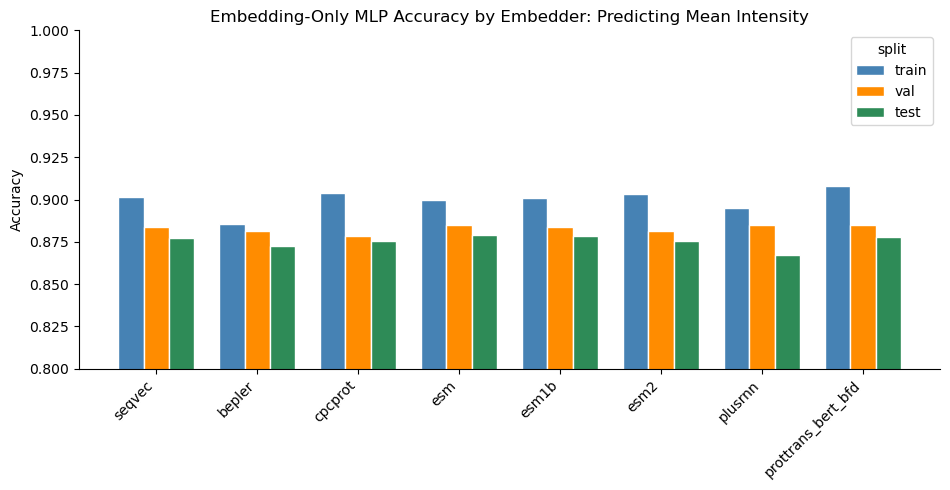

In [25]:
# accuracy across all embedders
plot_grouped_metric_by_embedder(clf_df, metric_prefix="accuracy", ylabel="Accuracy", ylim = (0.8, 1.0))


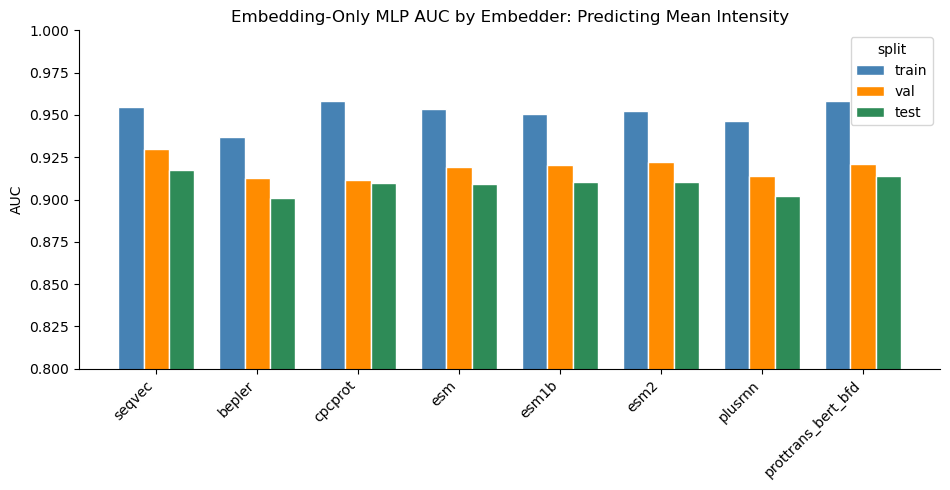

In [26]:
# auc across all embedders
plot_grouped_metric_by_embedder(clf_df, metric_prefix="auc", ylabel="AUC", ylim = (0.8, 1.0))

In [27]:
# compute specificity (true negative rate) per embedding/split from stored predictions
from sklearn.metrics import recall_score as _recall_score

specificity_rows = []
for embedding_name, data in all_predictions_dict.items():
    row = {"embedding": embedding_name}
    for split in ["train", "val", "test"]:
        y_true = data[f"y_{split}"]
        y_pred = data[f"y_pred_{split}"]
        row[f"{split}_specificity"] = round(_recall_score(y_true, y_pred, pos_label=0), 4)
    specificity_rows.append(row)

specificity_df = pd.DataFrame(specificity_rows)
clf_df = clf_df.merge(specificity_df, on="embedding", how="left")
clf_df.head()

,model,embedding,fusion_type,train_accuracy,val_accuracy,test_accuracy,train_f1,val_f1,test_f1,train_precision,...,train_specificity_x,val_specificity_x,test_specificity_x,train_auc,val_auc,test_auc,embedding_dim,train_specificity_y,val_specificity_y,test_specificity_y
0,embedding_only_mlp,seqvec,embedding_only,0.9015,0.8838,0.8775,0.9363,0.9251,0.9213,0.9351,...,0.7793,0.7485,0.7258,0.9549,0.9301,0.9175,1024,0.7793,0.7485,0.7258
1,embedding_only_mlp,bepler,embedding_only,0.8856,0.8815,0.8725,0.9267,0.9243,0.9192,0.9169,...,0.7121,0.7113,0.6660,0.9372,0.9128,0.9007,121,0.7121,0.7113,0.6660
2,embedding_only_mlp,cpcprot,embedding_only,0.9037,0.8783,0.8752,0.9386,0.9228,0.9215,0.9242,...,0.7349,0.6804,0.6433,0.9584,0.9114,0.9096,512,0.7349,0.6804,0.6433
3,embedding_only_mlp,esm,embedding_only,0.8998,0.8847,0.8793,0.9368,0.9271,0.9245,0.9134,...,0.6910,0.6825,0.6351,0.9535,0.9192,0.9090,1280,0.6910,0.6825,0.6351
4,embedding_only_mlp,esm1b,embedding_only,0.9010,0.8838,0.8784,0.9367,0.9260,0.9231,0.9249,...,0.7388,0.7072,0.6722,0.9507,0.9206,0.9106,1280,0.7388,0.7072,0.6722


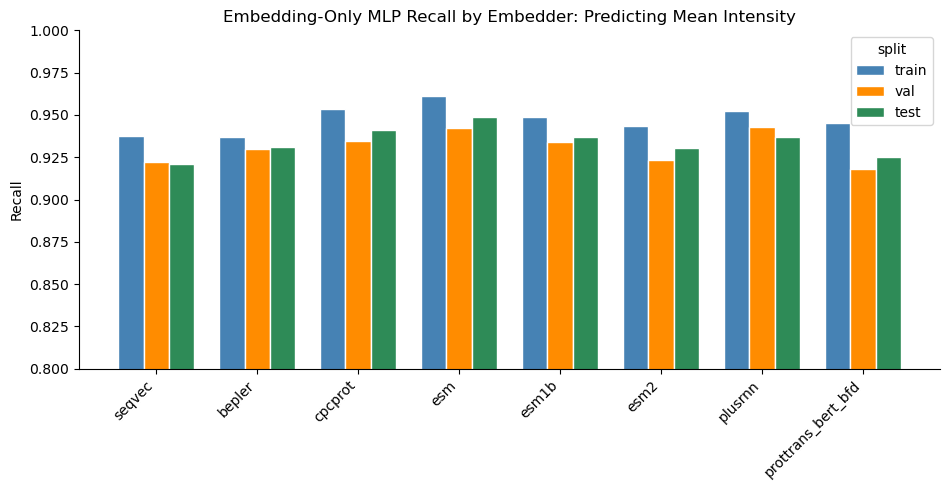

In [28]:
# recall across all embedders
plot_grouped_metric_by_embedder(clf_df, metric_prefix="recall", ylabel="Recall", ylim=(0.8, 1.0))

KeyError: 'train_specificity'

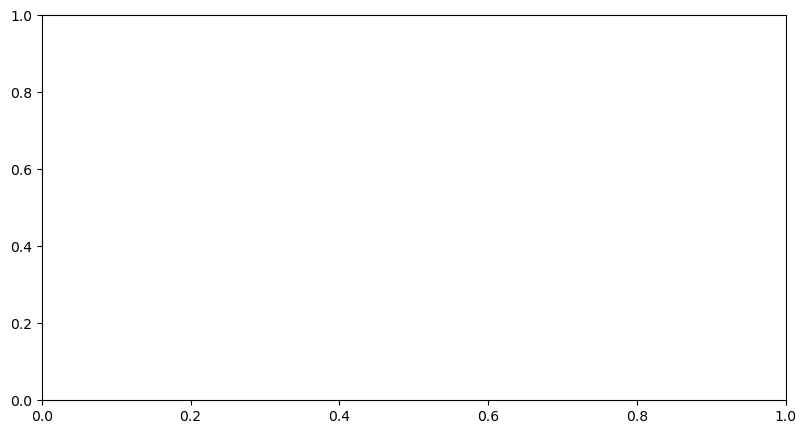

In [29]:
# specificity across all embedders
plot_grouped_metric_by_embedder(clf_df, metric_prefix="specificity", ylabel="Specificity", ylim=(0.5, 1.0))

In [ ]:
# confusion matrix for each embedder (test set)
n_embedders = len(all_predictions_dict)
n_cols = min(4, n_embedders)
n_rows = int(np.ceil(n_embedders / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)  # flatten in case of a single row

for i, (embedding_name, data) in enumerate(all_predictions_dict.items()):
    ax = axes[i]

    y_true = data["y_test"]
    y_pred = data["y_pred_test"]
    labels = sorted(np.unique(y_true))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(embedding_name)

    for r in range(len(labels)):
        for c in range(len(labels)):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="white" if cm[r, c] > cm.max() / 2 else "black")

# hide any unused subplots
for j in range(n_embedders, len(axes)):
    axes[j].axis("off")

fig.suptitle("Test Set Confusion Matrices by Embedder")
fig.tight_layout()
plt.show()